In [ ]:
!pip install -q torch torchvision transformers scikit-learn matplotlib seaborn pandas tqdm opencv-python yt-dlp datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.3/182.3 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 36.3 MB/s eta 0:00:00


In [ ]:
import os
import shutil
import zipfile

PROJECT_DIR = "/content/AI_Lab2_Video_Classification"
os.makedirs(PROJECT_DIR, exist_ok=True)

uploaded_zip = "/content/HowTo100M.zip"
zip_path = os.path.join(PROJECT_DIR, "HowTo100M.zip")

if os.path.exists(uploaded_zip):
    shutil.copy(uploaded_zip, zip_path)
    print("Архив скопирован в:", zip_path)
else:
    print("Файл /content/HowTo100M.zip не найден. Проверь имя файла в левой панели Colab.")

print("Размер файла:")
!ls -lh "{zip_path}"

Файл /content/HowTo100M.zip не найден. Проверь имя файла в левой панели Colab.
Размер файла:
ls: cannot access '/content/AI_Lab2_Video_Classification/HowTo100M.zip': No such file or directory


In [ ]:
import os

HOWTO_ZIP_URL = "https://www.rocq.inria.fr/cluster-willow/amiech/howto100m/HowTo100M.zip"
zip_path = os.path.join(PROJECT_DIR, "HowTo100M.zip")

if not os.path.exists(zip_path):
    !wget -c -O "{zip_path}" "{HOWTO_ZIP_URL}"
else:
    print("Архив уже скачан:", zip_path)

--2026-05-13 12:50:03--  https://www.rocq.inria.fr/cluster-willow/amiech/howto100m/HowTo100M.zip
Resolving www.rocq.inria.fr (www.rocq.inria.fr)... 128.93.96.7
Connecting to www.rocq.inria.fr (www.rocq.inria.fr)|128.93.96.7|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1993427357 (1.9G) [application/zip]
Saving to: ‘/content/AI_Lab2_Video_Classification/HowTo100M.zip’

/content/AI_Lab2_Vi 100%[===================>]   1.86G  1.39MB/s    in 8m 28s  

2026-05-13 12:58:33 (3.74 MB/s) - ‘/content/AI_Lab2_Video_Classification/HowTo100M.zip’ saved [1993427357/1993427357]



In [ ]:
import zipfile

with zipfile.ZipFile(zip_path, "r") as z:
    names = z.namelist()
    print("Количество файлов в архиве:", len(names))
    for name in names:
        print(name)

Количество файлов в архиве: 5
caption.json
README.txt
HowTo100M_v1.csv
task_ids.csv
s3d_features_readme.txt


In [ ]:
import zipfile
import os

EXTRACT_DIR = os.path.join(PROJECT_DIR, "metadata")
os.makedirs(EXTRACT_DIR, exist_ok=True)

needed_files = ["HowTo100M_v1.csv", "task_ids.csv"]

with zipfile.ZipFile(zip_path, "r") as z:
    for target in needed_files:
        matched = [name for name in z.namelist() if name.endswith(target)]
        if len(matched) == 0:
            print("Не найден файл:", target)
        else:
            file_in_zip = matched[0]
            print("Извлекаем:", file_in_zip)
            z.extract(file_in_zip, EXTRACT_DIR)

print("Готово")

Извлекаем: HowTo100M_v1.csv
Извлекаем: task_ids.csv
Готово


In [ ]:
import os

csv_files = []

for root, dirs, files in os.walk(EXTRACT_DIR):
    for file in files:
        if file.endswith(".csv"):
            csv_files.append(os.path.join(root, file))

csv_files

['/content/AI_Lab2_Video_Classification/metadata/HowTo100M_v1.csv',
 '/content/AI_Lab2_Video_Classification/metadata/task_ids.csv']

In [ ]:
import pandas as pd

howto_csv = [p for p in csv_files if p.endswith("HowTo100M_v1.csv")][0]
task_csv = [p for p in csv_files if p.endswith("task_ids.csv")][0]

df_meta = pd.read_csv(howto_csv)
df_tasks = pd.read_csv(task_csv, sep="\t", header=None, names=["task_id", "task_description"])

print("Metadata shape:", df_meta.shape)
print("Tasks shape:", df_tasks.shape)

display(df_meta.head())
display(df_tasks.head())

Metadata shape: (1238911, 5)
Tasks shape: (123520, 2)


,video_id,category_1,category_2,rank,task_id
0,nVbIUDjzWY4,Cars & Other Vehicles,Motorcycles,27,52907
1,CTPAZ2euJ2Q,Cars & Other Vehicles,Motorcycles,35,109057
2,rwmt7Cbuvfs,Cars & Other Vehicles,Motorcycles,99,52907
3,HnTLh99gcxY,Cars & Other Vehicles,Motorcycles,35,52907
4,EyP3HVhg1u0,Cars & Other Vehicles,Motorcycles,95,52906


,task_id,task_description
0,0,Make a Mexican Bean Toast
1,1,Make a Cinnamon Toast Sandwich
2,2,Make Avocado on Toast
3,3,Make Baked Peach French Toast
4,4,Make Buttered Toast


In [ ]:
df = df_meta.merge(df_tasks, on="task_id", how="left")

print(df.shape)

display(df.head())
print(df.columns)


(1238911, 6)


,video_id,category_1,category_2,rank,task_id,task_description
0,nVbIUDjzWY4,Cars & Other Vehicles,Motorcycles,27,52907,Paint a Motorcycle
1,CTPAZ2euJ2Q,Cars & Other Vehicles,Motorcycles,35,109057,Clean Engine Cylinder Heads
2,rwmt7Cbuvfs,Cars & Other Vehicles,Motorcycles,99,52907,Paint a Motorcycle
3,HnTLh99gcxY,Cars & Other Vehicles,Motorcycles,35,52907,Paint a Motorcycle
4,EyP3HVhg1u0,Cars & Other Vehicles,Motorcycles,95,52906,Paint a Motorcycle Tank


Index(['video_id', 'category_1', 'category_2', 'rank', 'task_id',
       'task_description'],
      dtype='object')


In [ ]:
print("Топ-20 category_1:")
print(df["category_1"].value_counts().head(20))

Топ-20 category_1:
category_1
Food and Entertaining           498475
Home and Garden                 270135
Hobbies and Crafts              255865
Cars & Other Vehicles            68809
Pets and Animals                 31129
Holidays and Traditions          27837
Personal Care and Style          16075
Sports and Fitness               15976
Health                           15664
Education and Communications     15350
Arts and Entertainment            9763
Computers and Electronics         5286
Youth                             1111
Family Life                       1041
Finance and Business               792
Work World                         590
Philosophy and Religion            491
Travel                             194
Relationships                       39
Name: count, dtype: int64


In [ ]:
SAMPLES_PER_CATEGORY = 500

SELECTED_CATEGORIES = df["category_1"].value_counts().head(4).index.tolist()

print("Выбранные категории:", SELECTED_CATEGORIES)

subset_parts = []

for cat in SELECTED_CATEGORIES:
    part = df[df["category_1"] == cat].sample(
        n=SAMPLES_PER_CATEGORY,
        random_state=42
    )
    subset_parts.append(part)

subset_df = pd.concat(subset_parts).sample(frac=1, random_state=42).reset_index(drop=True)

subset_df = subset_df.rename(columns={"category_1": "category"})
subset_df["text"] = subset_df["task_description"].fillna("").astype(str)

subset_df = subset_df[[
    "video_id",
    "category",
    "category_2",
    "rank",
    "task_id",
    "task_description",
    "text"
]]

print("Размер исходной подвыборки:", len(subset_df))
print(subset_df["category"].value_counts())

display(subset_df.head())

Выбранные категории: ['Food and Entertaining', 'Home and Garden', 'Hobbies and Crafts', 'Cars & Other Vehicles']
Размер исходной подвыборки: 2000
category
Cars & Other Vehicles    500
Food and Entertaining    500
Hobbies and Crafts       500
Home and Garden          500
Name: count, dtype: int64


,video_id,category,category_2,rank,task_id,task_description,text
0,sddxEU2LtY8,Cars & Other Vehicles,Boats,107,32305,Properly Flush a 2 Stroke Jet Ski/Sea Doo/Wave...,Properly Flush a 2 Stroke Jet Ski/Sea Doo/Wave...
1,Y0dpE7NNjmE,Food and Entertaining,Recipes,9,6201,Freeze Okra,Freeze Okra
2,KLkNGdtgaIg,Hobbies and Crafts,Crafts,142,93268,Make Natural Liquid Soap,Make Natural Liquid Soap
3,_jwWvTfdQZA,Home and Garden,Landscaping and Outdoor Building,159,93222,Make Your Pavers Level,Make Your Pavers Level
4,0tPEGx7nRBM,Hobbies and Crafts,Crafts,181,92829,Paint a Rock Using Toothpicks,Paint a Rock Using Toothpicks


In [ ]:
import os
import cv2
import subprocess
import ast
import numpy as np
import pandas as pd
from tqdm import tqdm
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from transformers import CLIPProcessor, CLIPModel

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    top_k_accuracy_score
)

import matplotlib.pyplot as plt
import seaborn as sns

VIDEO_DIR = os.path.join(PROJECT_DIR, "videos_15s")
FRAME_DIR = os.path.join(PROJECT_DIR, "frames")

os.makedirs(VIDEO_DIR, exist_ok=True)
os.makedirs(FRAME_DIR, exist_ok=True)

print("Video dir:", VIDEO_DIR)
print("Frame dir:", FRAME_DIR)

Video dir: /content/AI_Lab2_Video_Classification/videos_15s
Frame dir: /content/AI_Lab2_Video_Classification/frames


In [ ]:
subset_path = os.path.join(PROJECT_DIR, "howto100m_subset_2000.csv")
subset_df.to_csv(subset_path, index=False)

print("Сохранено:", subset_path)

Сохранено: /content/AI_Lab2_Video_Classification/howto100m_subset_2000.csv


In [ ]:
def download_video_clip(video_id, save_dir=VIDEO_DIR, duration_sec=15):
    output_template = os.path.join(save_dir, f"{video_id}.%(ext)s")
    final_path = os.path.join(save_dir, f"{video_id}.mp4")

    if os.path.exists(final_path) and os.path.getsize(final_path) > 100_000:
        return final_path

    url = f"https://www.youtube.com/watch?v={video_id}"

    command = [
        "yt-dlp",
        "--no-playlist",
        "--quiet",
        "--no-warnings",
        "-f", "worst[ext=mp4]/worst",
        "--download-sections", f"*00:00:00-00:00:{duration_sec:02d}",
        "--force-keyframes-at-cuts",
        "--merge-output-format", "mp4",
        "-o", output_template,
        url
    ]

    try:
        subprocess.run(
            command,
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            timeout=120
        )

        if os.path.exists(final_path) and os.path.getsize(final_path) > 100_000:
            return final_path

        possible_files = [
            os.path.join(save_dir, f)
            for f in os.listdir(save_dir)
            if f.startswith(video_id)
        ]

        for file in possible_files:
            if file.endswith(".mp4") and os.path.getsize(file) > 100_000:
                return file

        return None

    except Exception:
        return None

In [ ]:
def extract_frames_from_video(video_path, video_id, frame_dir=FRAME_DIR, num_frames=4):
    save_dir = os.path.join(frame_dir, video_id)
    os.makedirs(save_dir, exist_ok=True)

    existing_frames = [
        os.path.join(save_dir, f)
        for f in os.listdir(save_dir)
        if f.endswith(".jpg")
    ]

    if len(existing_frames) >= num_frames:
        return sorted(existing_frames)[:num_frames]

    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        return []

    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if frame_count <= 0:
        cap.release()
        return []

    frame_indices = np.linspace(
        0,
        frame_count - 1,
        num=num_frames,
        dtype=int
    )

    saved_frames = []

    for idx, frame_idx in enumerate(frame_indices):
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_idx))
        success, frame = cap.read()

        if not success or frame is None:
            continue

        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        frame_path = os.path.join(save_dir, f"frame_{idx}.jpg")
        Image.fromarray(frame).save(frame_path)

        saved_frames.append(frame_path)

    cap.release()

    return saved_frames

In [ ]:
TARGET_PROCESSED = 1000
NUM_FRAMES_PER_VIDEO = 4
CLIP_DURATION_SEC = 15

processed_rows = []

for _, row in tqdm(subset_df.iterrows(), total=len(subset_df)):
    video_id = row["video_id"]

    video_path = download_video_clip(
        video_id=video_id,
        duration_sec=CLIP_DURATION_SEC
    )

    if video_path is None:
        continue

    frame_paths = extract_frames_from_video(
        video_path=video_path,
        video_id=video_id,
        num_frames=NUM_FRAMES_PER_VIDEO
    )

    if len(frame_paths) == 0:
        continue

    processed_rows.append({
        "video_id": video_id,
        "category": row["category"],
        "category_2": row["category_2"],
        "rank": row["rank"],
        "task_id": row["task_id"],
        "task_description": row["task_description"],
        "text": row["text"],
        "video_path": video_path,
        "frame_paths": frame_paths
    })

    if len(processed_rows) >= TARGET_PROCESSED:
        break

processed_df = pd.DataFrame(processed_rows)

print("Успешно обработано видео:", len(processed_df))

if len(processed_df) < TARGET_PROCESSED:
    print("ВНИМАНИЕ: обработано меньше 1000 видео.")
    print("Увеличьте SAMPLES_PER_CATEGORY, например до 800, и перезапустите блок формирования subset_df.")

if len(processed_df) > 0:
    print(processed_df["category"].value_counts())
    display(processed_df.head())

processed_path = os.path.join(PROJECT_DIR, "howto100m_processed_video_frames.csv")
processed_df.to_csv(processed_path, index=False)

print("Сохранено:", processed_path)

 60%|█████▉    | 1194/2000 [2:30:44<1:41:45,  7.57s/it]

Успешно обработано видео: 1000
category
Food and Entertaining    273
Cars & Other Vehicles    265
Home and Garden          239
Hobbies and Crafts       223
Name: count, dtype: int64


,video_id,category,category_2,rank,task_id,task_description,text,video_path,frame_paths
0,sddxEU2LtY8,Cars & Other Vehicles,Boats,107,32305,Properly Flush a 2 Stroke Jet Ski/Sea Doo/Wave...,Properly Flush a 2 Stroke Jet Ski/Sea Doo/Wave...,/content/AI_Lab2_Video_Classification/videos_1...,[/content/AI_Lab2_Video_Classification/frames/...
1,Y0dpE7NNjmE,Food and Entertaining,Recipes,9,6201,Freeze Okra,Freeze Okra,/content/AI_Lab2_Video_Classification/videos_1...,[/content/AI_Lab2_Video_Classification/frames/...
2,KLkNGdtgaIg,Hobbies and Crafts,Crafts,142,93268,Make Natural Liquid Soap,Make Natural Liquid Soap,/content/AI_Lab2_Video_Classification/videos_1...,[/content/AI_Lab2_Video_Classification/frames/...
3,_jwWvTfdQZA,Home and Garden,Landscaping and Outdoor Building,159,93222,Make Your Pavers Level,Make Your Pavers Level,/content/AI_Lab2_Video_Classification/videos_1...,[/content/AI_Lab2_Video_Classification/frames/...
4,0tPEGx7nRBM,Hobbies and Crafts,Crafts,181,92829,Paint a Rock Using Toothpicks,Paint a Rock Using Toothpicks,/content/AI_Lab2_Video_Classification/videos_1...,[/content/AI_Lab2_Video_Classification/frames/...


Сохранено: /content/AI_Lab2_Video_Classification/howto100m_processed_video_frames.csv


In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

clip_model_name = "openai/clip-vit-base-patch32"

clip_model = CLIPModel.from_pretrained(clip_model_name).to(DEVICE)
clip_processor = CLIPProcessor.from_pretrained(clip_model_name)

clip_model.eval()

Device: cpu


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05,

In [ ]:
@torch.no_grad()
def get_text_embeddings(texts, batch_size=32):
    all_embeddings = []

    for i in tqdm(range(0, len(texts), batch_size)):
        batch_texts = texts[i:i + batch_size]

        inputs = clip_processor(
            text=batch_texts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=77
        ).to(DEVICE)

        outputs = clip_model.get_text_features(**inputs)

        if hasattr(outputs, "pooler_output"):
            text_features = outputs.pooler_output
        else:
            text_features = outputs

        text_features = text_features / text_features.norm(dim=-1, keepdim=True)

        all_embeddings.append(text_features.cpu().numpy())

    return np.vstack(all_embeddings)


texts = processed_df["text"].fillna("").astype(str).tolist()

text_embeddings = get_text_embeddings(texts, batch_size=32)

print("Text embeddings shape:", text_embeddings.shape)


100%|██████████| 32/32 [00:29<00:00,  1.08it/s]

Text embeddings shape: (1000, 512)


In [ ]:
@torch.no_grad()
def get_single_video_embedding(frame_paths):
    images = []

    for path in frame_paths:
        image = Image.open(path).convert("RGB")
        images.append(image)

    inputs = clip_processor(
        images=images,
        return_tensors="pt"
    ).to(DEVICE)

    outputs = clip_model.get_image_features(**inputs)

    if hasattr(outputs, "pooler_output"):
        frame_features = outputs.pooler_output
    else:
        frame_features = outputs

    frame_features = frame_features / frame_features.norm(dim=-1, keepdim=True)

    video_features = frame_features.mean(dim=0)
    video_features = video_features / video_features.norm(dim=-1, keepdim=True)

    return video_features.cpu().numpy()


@torch.no_grad()
def get_video_embeddings(processed_df):
    all_embeddings = []

    for _, row in tqdm(processed_df.iterrows(), total=len(processed_df)):
        frame_paths = row["frame_paths"]

        if isinstance(frame_paths, str):
            frame_paths = ast.literal_eval(frame_paths)

        video_embedding = get_single_video_embedding(frame_paths)
        all_embeddings.append(video_embedding)

    return np.vstack(all_embeddings)


video_embeddings = get_video_embeddings(processed_df)

print("Video embeddings shape:", video_embeddings.shape)


100%|██████████| 1000/1000 [12:59<00:00,  1.28it/s]

Video embeddings shape: (1000, 512)


In [ ]:
X = np.concatenate([text_embeddings, video_embeddings], axis=1)

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(processed_df["category"])

print("Combined embeddings shape:", X.shape)
print("Classes:", list(label_encoder.classes_))
print("Number of classes:", len(label_encoder.classes_))

Combined embeddings shape: (1000, 1024)
Classes: ['Cars & Other Vehicles', 'Food and Entertaining', 'Hobbies and Crafts', 'Home and Garden']
Number of classes: 4


In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Train: (700, 1024)
Val: (150, 1024)
Test: (150, 1024)


In [ ]:
from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = 64

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(X_val_tensor, y_val_tensor),
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    TensorDataset(X_test_tensor, y_test_tensor),
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [ ]:
class CrossModalClassifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(CrossModalClassifier, self).__init__()

        self.classifier = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(p=0.3),

            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(p=0.2),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.classifier(x)


input_dim = X.shape[1]
num_classes = len(label_encoder.classes_)

model = CrossModalClassifier(
    input_dim=input_dim,
    num_classes=num_classes
).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

print(model)

CrossModalClassifier(
  (classifier): Sequential(
    (0): Linear(in_features=1024, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=512, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=128, out_features=4, bias=True)
  )
)


In [ ]:
def evaluate_model(model, loader):
    model.eval()

    all_preds = []
    all_labels = []
    all_probs = []

    total_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(outputs, dim=1)

            total_loss += loss.item()

            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(loader)

    accuracy = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    return avg_loss, accuracy, precision, recall, f1, np.array(all_probs), np.array(all_labels), np.array(all_preds)


NUM_EPOCHS = 30

history = {
    "train_loss": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_precision": [],
    "val_recall": [],
    "val_f1": []
}

best_val_f1 = 0.0
best_model_path = os.path.join(PROJECT_DIR, "best_cross_modal_video_classifier.pth")

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    val_loss, val_acc, val_precision, val_recall, val_f1, _, _, _ = evaluate_model(model, val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_acc)
    history["val_precision"].append(val_precision)
    history["val_recall"].append(val_recall)
    history["val_f1"].append(val_f1)

    print(
        f"Epoch {epoch+1}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Val F1: {val_f1:.4f}"
    )

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), best_model_path)

print("Best Val F1:", best_val_f1)

Epoch 1/30 | Train Loss: 1.3434 | Val Loss: 1.2391 | Val Acc: 0.5733 | Val F1: 0.4827
Epoch 2/30 | Train Loss: 1.0888 | Val Loss: 0.8296 | Val Acc: 0.6733 | Val F1: 0.6325
Epoch 3/30 | Train Loss: 0.7183 | Val Loss: 0.5075 | Val Acc: 0.8667 | Val F1: 0.8678
Epoch 4/30 | Train Loss: 0.4847 | Val Loss: 0.3626 | Val Acc: 0.8933 | Val F1: 0.8943
Epoch 5/30 | Train Loss: 0.3628 | Val Loss: 0.2952 | Val Acc: 0.9000 | Val F1: 0.9003
Epoch 6/30 | Train Loss: 0.2815 | Val Loss: 0.2749 | Val Acc: 0.8867 | Val F1: 0.8882
Epoch 7/30 | Train Loss: 0.2458 | Val Loss: 0.2588 | Val Acc: 0.8933 | Val F1: 0.8938
Epoch 8/30 | Train Loss: 0.2026 | Val Loss: 0.2739 | Val Acc: 0.9133 | Val F1: 0.9139
Epoch 9/30 | Train Loss: 0.1685 | Val Loss: 0.2673 | Val Acc: 0.9267 | Val F1: 0.9272
Epoch 10/30 | Train Loss: 0.1310 | Val Loss: 0.2704 | Val Acc: 0.9000 | Val F1: 0.9003
Epoch 11/30 | Train Loss: 0.1089 | Val Loss: 0.2995 | Val Acc: 0.8933 | Val F1: 0.8948
Epoch 12/30 | Train Loss: 0.0989 | Val Loss: 0.2841 

In [ ]:
model.load_state_dict(torch.load(best_model_path))

test_loss, test_acc, test_precision, test_recall, test_f1, test_probs, test_labels, test_preds = evaluate_model(
    model,
    test_loader
)

top2_acc = top_k_accuracy_score(
    test_labels,
    test_probs,
    k=2,
    labels=np.arange(num_classes)
)

print("TEST RESULTS")
print(f"Loss:      {test_loss:.4f}")
print(f"Accuracy:  {test_acc:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-score:  {test_f1:.4f}")
print(f"Top-2 Acc: {top2_acc:.4f}")

TEST RESULTS
Loss:      0.3433
Accuracy:  0.8867
Precision: 0.8968
Recall:    0.8867
F1-score:  0.8878
Top-2 Acc: 0.9733


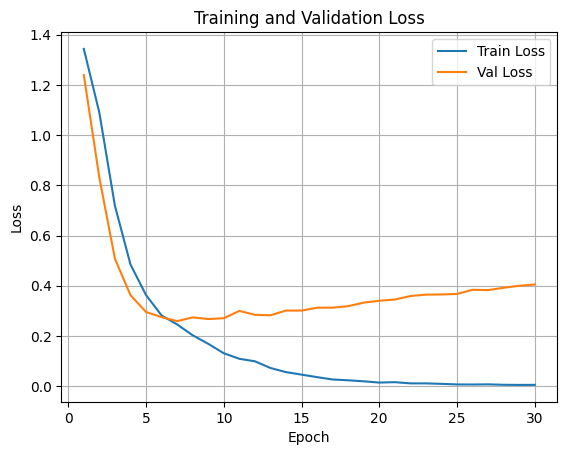

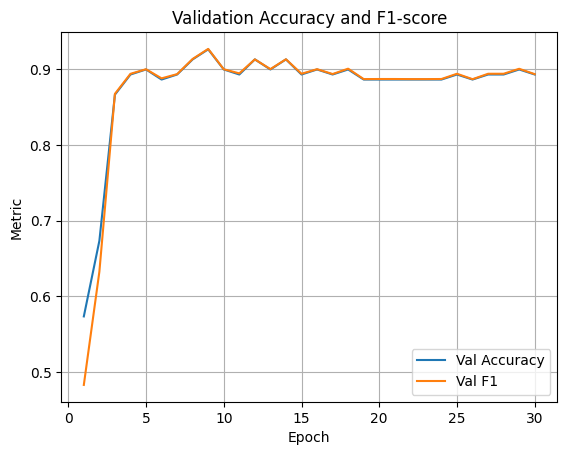

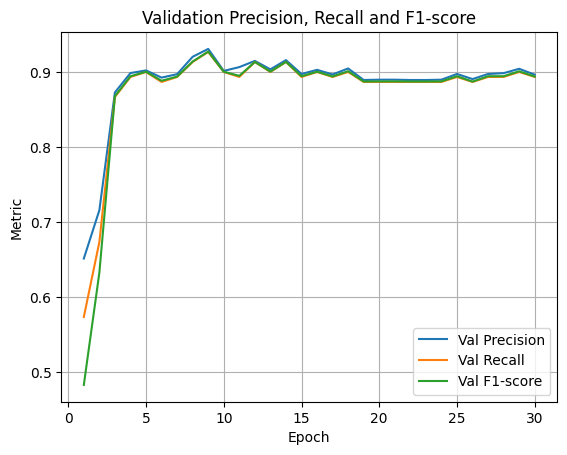

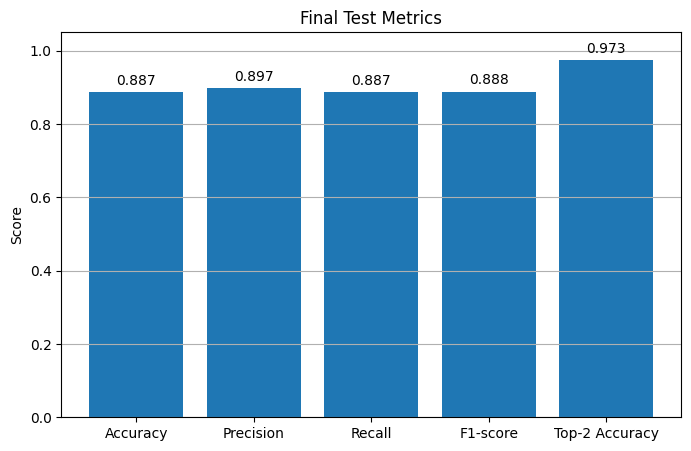

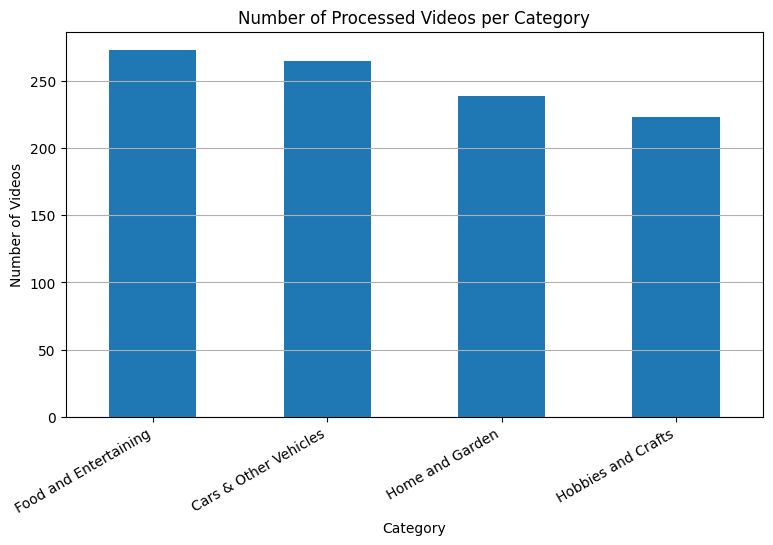

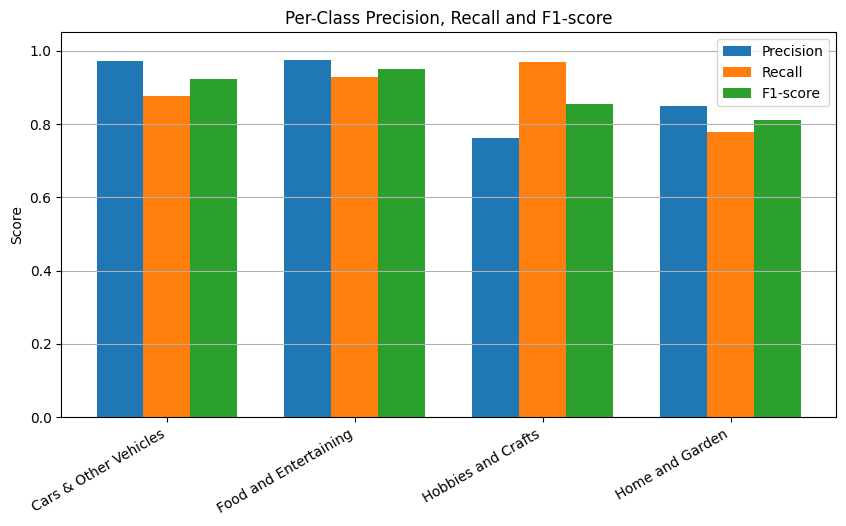

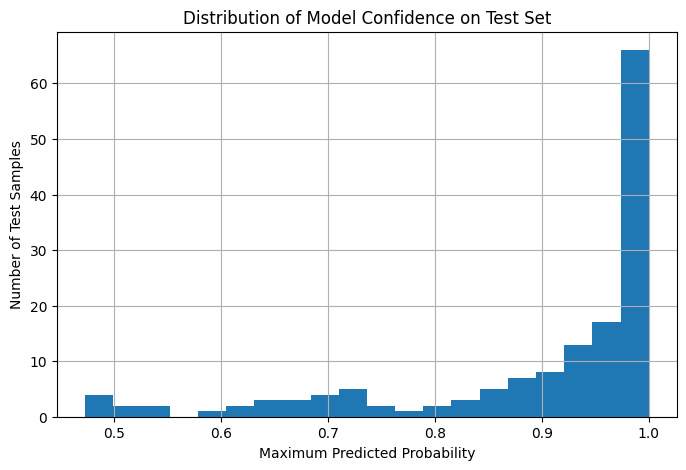

In [ ]:
epochs = range(1, NUM_EPOCHS + 1)

plt.figure()
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(epochs, history["val_accuracy"], label="Val Accuracy")
plt.plot(epochs, history["val_f1"], label="Val F1")
plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.title("Validation Accuracy and F1-score")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(epochs, history["val_precision"], label="Val Precision")
plt.plot(epochs, history["val_recall"], label="Val Recall")
plt.plot(epochs, history["val_f1"], label="Val F1-score")
plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.title("Validation Precision, Recall and F1-score")
plt.legend()
plt.grid(True)
plt.show()

test_metrics = {
    "Accuracy": test_acc,
    "Precision": test_precision,
    "Recall": test_recall,
    "F1-score": test_f1,
    "Top-2 Accuracy": top2_acc
}

plt.figure(figsize=(8, 5))
plt.bar(test_metrics.keys(), test_metrics.values())
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Final Test Metrics")

for i, value in enumerate(test_metrics.values()):
    plt.text(i, value + 0.02, f"{value:.3f}", ha="center")

plt.grid(axis="y")
plt.show()


plt.figure(figsize=(9, 5))
processed_df["category"].value_counts().plot(kind="bar")
plt.title("Number of Processed Videos per Category")
plt.xlabel("Category")
plt.ylabel("Number of Videos")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y")
plt.show()

from sklearn.metrics import precision_recall_fscore_support

class_precision, class_recall, class_f1, class_support = precision_recall_fscore_support(
    test_labels,
    test_preds,
    average=None,
    zero_division=0
)

class_names = label_encoder.classes_

x = np.arange(len(class_names))
width = 0.25

plt.figure(figsize=(10, 5))
plt.bar(x - width, class_precision, width, label="Precision")
plt.bar(x, class_recall, width, label="Recall")
plt.bar(x + width, class_f1, width, label="F1-score")

plt.xticks(x, class_names, rotation=30, ha="right")
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Per-Class Precision, Recall and F1-score")
plt.legend()
plt.grid(axis="y")
plt.show()


max_probs = np.max(test_probs, axis=1)

plt.figure(figsize=(8, 5))
plt.hist(max_probs, bins=20)
plt.xlabel("Maximum Predicted Probability")
plt.ylabel("Number of Test Samples")
plt.title("Distribution of Model Confidence on Test Set")
plt.grid(True)
plt.show()


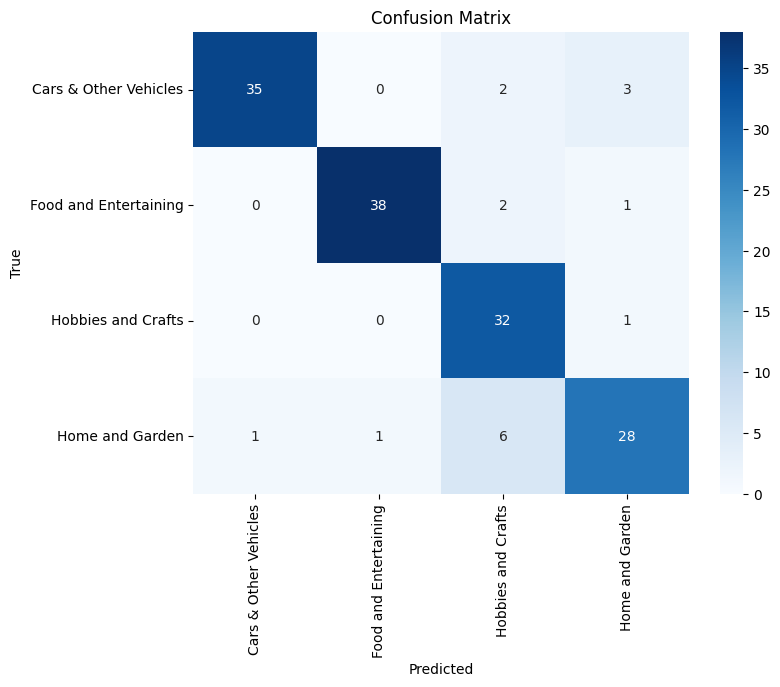

                       precision    recall  f1-score   support

Cars & Other Vehicles       0.97      0.88      0.92        40
Food and Entertaining       0.97      0.93      0.95        41
   Hobbies and Crafts       0.76      0.97      0.85        33
      Home and Garden       0.85      0.78      0.81        36

             accuracy                           0.89       150
            macro avg       0.89      0.89      0.88       150
         weighted avg       0.90      0.89      0.89       150



In [ ]:
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(
    test_labels,
    test_preds,
    target_names=label_encoder.classes_,
    zero_division=0
))